In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score



### Wczytanie danych i podstawowa analiza

In [107]:
dataset = fetch_ucirepo(id=365)
X = dataset.data.features
y = dataset.data.targets

In [108]:
df = X.copy()
df['class'] = y['class']

In [109]:
df

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,1,0.20,0.38,0.40,2.05,32.35,0.39,0.25,1.33,1.14,...,0.12,0.40,0.88,0.00,8.42,5.14,82.66,4.42,7.43,0
1,1,0.21,0.50,0.47,1.94,14.79,0.00,0.26,1.00,1.70,...,0.12,0.42,0.85,0.00,4.15,3.27,107.35,3.40,60.99,0
2,1,0.25,0.70,0.27,1.55,-1.15,0.00,0.31,0.44,1.31,...,0.24,0.82,0.77,0.69,4.99,3.95,134.27,2.72,5.21,0
3,1,0.08,0.31,0.46,2.49,51.95,0.15,0.09,1.87,1.06,...,0.05,0.14,0.95,0.00,4.57,3.61,86.44,4.22,5.55,0
4,1,0.19,0.61,0.23,1.41,-7.31,0.19,0.19,0.63,1.16,...,0.13,0.48,0.87,0.12,6.40,4.32,127.21,2.87,7.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43400,5,0.01,0.71,0.04,1.17,-18.91,0.00,0.01,0.42,1.68,...,0.02,0.04,1.01,1.26,13.47,12.43,49.12,7.43,2.28,1
43401,5,-0.58,0.97,-0.80,0.17,-67.36,-0.58,-0.58,-0.40,0.94,...,-0.06,1.48,1.06,-0.02,110.72,44.76,81.22,4.49,5.13,1
43402,5,-0.18,1.26,-0.28,0.75,-120.44,-0.18,-0.15,-0.26,1.17,...,0.15,0.55,0.85,-0.52,9.85,3.49,207.87,1.76,9.95,1
43403,5,-0.11,0.74,0.02,1.09,-17.00,-0.11,-0.11,0.13,0.85,...,-0.18,-1.17,1.18,6.09,13.89,6.08,83.12,4.39,0.96,1


In [110]:
print(f"Full dataset shape: {df.shape}")
print(f"Years available: {sorted(df['year'].unique())}")
print()

for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    n = len(subset)
    n_bankrupt = (subset['class'] == 1).sum()
    n_missing = subset.drop(columns=['class']).isnull().sum().sum()
    n_cells = subset.drop(columns=['class', 'year']).size
    print(f"Year {year}: {n} rows, "
          f"bankrupt {n_bankrupt} ({100*n_bankrupt/n:.1f}%), "
          f"missing {n_missing} ({100*n_missing/n_cells:.1f}% cells)")

Full dataset shape: (43405, 66)
Years available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Year 1: 7027 rows, bankrupt 271 (3.9%), missing 5835 (1.3% cells)
Year 2: 10173 rows, bankrupt 400 (3.9%), missing 12157 (1.9% cells)
Year 3: 10503 rows, bankrupt 495 (4.7%), missing 9888 (1.5% cells)
Year 4: 9792 rows, bankrupt 515 (5.3%), missing 8776 (1.4% cells)
Year 5: 5910 rows, bankrupt 410 (6.9%), missing 4666 (1.2% cells)


wybieramy Year 4 

In [111]:
df = X.copy()
df['class'] = y['class']
df = df[df['year'] == 4].drop(columns=['year'])

X = df.drop(columns=['class'])
y = df['class']
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print(f"Shape: {X.shape}")
print(f"Bankrupt: {(y==1).sum()} ({100*(y==1).mean():.1f}%)")
print(f"Not bankrupt: {(y==0).sum()} ({100*(y==0).mean():.1f}%)")
print(f"\nMissing values: {X.isnull().sum().sum()} ({100*X.isnull().sum().sum()/X.size:.1f}% cells)")

Shape: (9792, 64)
Bankrupt: 515 (5.3%)
Not bankrupt: 9277 (94.7%)

Missing values: 8776 (1.4% cells)


In [112]:
pd.set_option('display.float_format', '{:.2f}'.format)

desc = X.describe().T
desc['missing_%'] = (X.isnull().sum() / len(X) * 100).round(1)

print(desc[['mean', 'std', 'min', '50%', 'max', 'missing_%']].to_string())

       mean       std         min    50%         max  missing_%
A1     0.04      0.36      -12.46   0.04       20.48       0.00
A2     0.60      4.59        0.00   0.47      446.91       0.00
A3     0.13      4.56     -445.91   0.20       22.77       0.00
A4     8.14    290.65       -0.05   1.59    27146.00       0.40
A5    64.26  14732.27  -379000.00  -0.06  1030000.00       0.20
A6    -0.06      6.81     -486.82   0.00      322.20       0.00
A7     0.06      0.53      -12.46   0.05       38.62       0.00
A8    19.88    698.70       -1.85   1.09    53209.00       0.20
A9     1.88     17.67       -0.03   1.16     1704.80       0.00
A10    0.39      4.59     -445.91   0.51       12.60       0.00
A11    0.08      0.53      -12.24   0.06       38.62       0.00
A12    0.21     74.24    -6331.80   0.14     3340.90       0.40
A13    0.40     37.97    -1460.60   0.06     2707.70       0.20
A14    0.06      0.53      -12.46   0.05       38.62       0.00
A15 3018.65 102317.01 -1570000.00 906.56

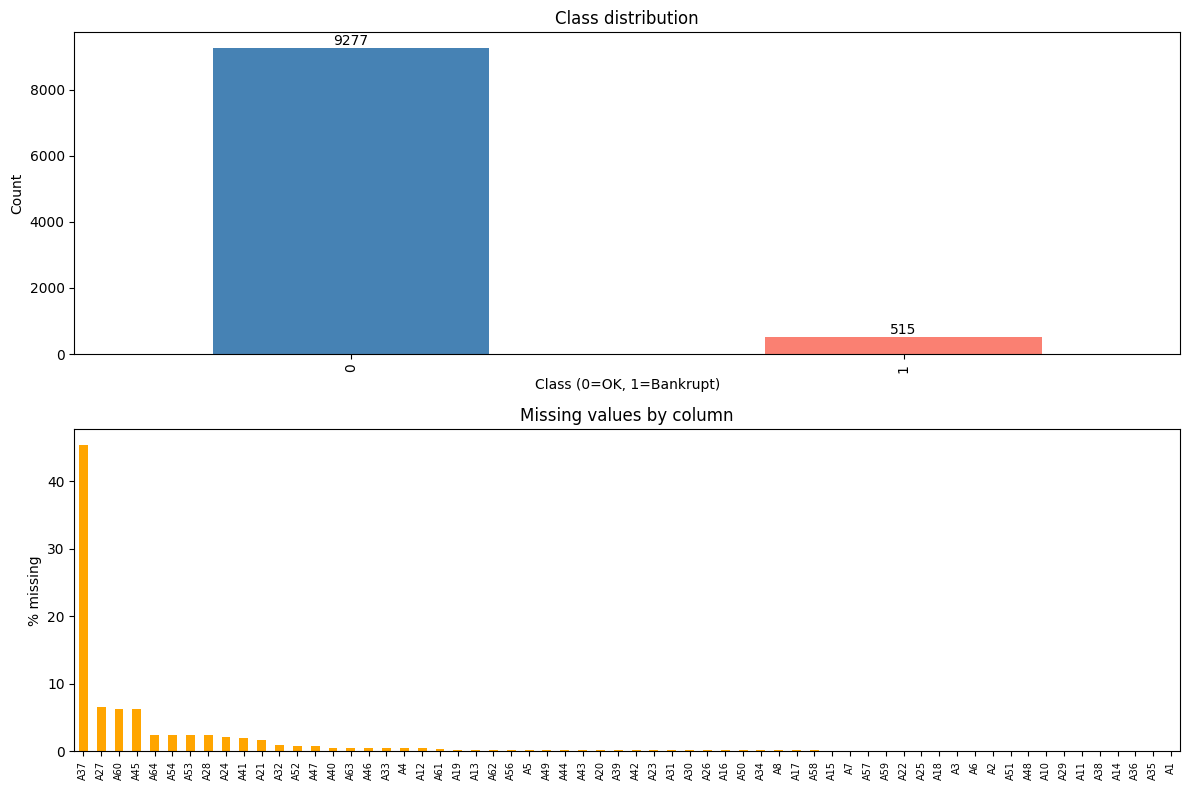

In [113]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Class distribution
y.value_counts().plot.bar(ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Class distribution')
axes[0].set_xlabel('Class (0=OK, 1=Bankrupt)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

# Missing values per column
missing = (X.isnull().sum() / len(X) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot.bar(ax=axes[1], color='orange')
axes[1].set_title('Missing values by column')
axes[1].set_ylabel('% missing')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

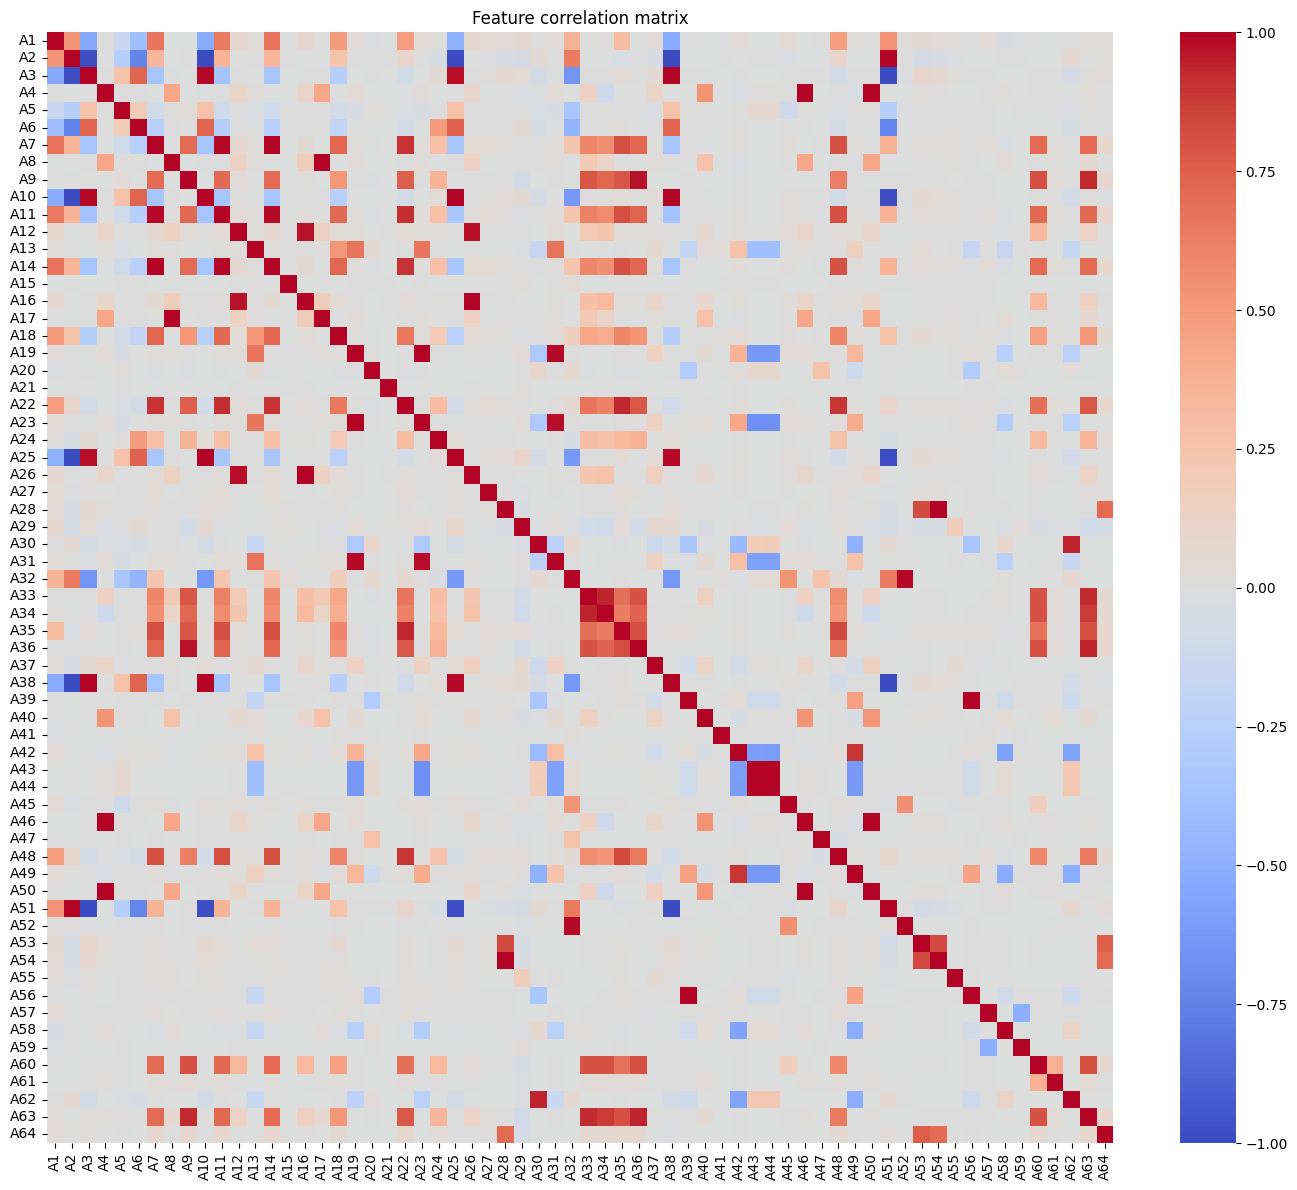

In [114]:
corr = X.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, linewidths=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

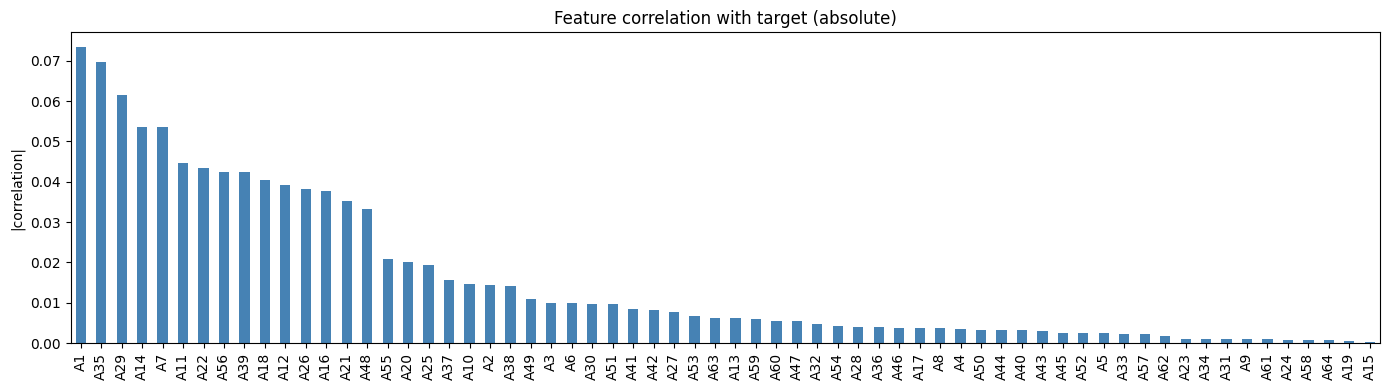

In [115]:
correlations = X.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
correlations.plot.bar(color='steelblue')
plt.title('Feature correlation with target (absolute)')
plt.ylabel('|correlation|')
plt.tight_layout()
plt.show()

sample_cols = correlations.head(6).index.tolist()

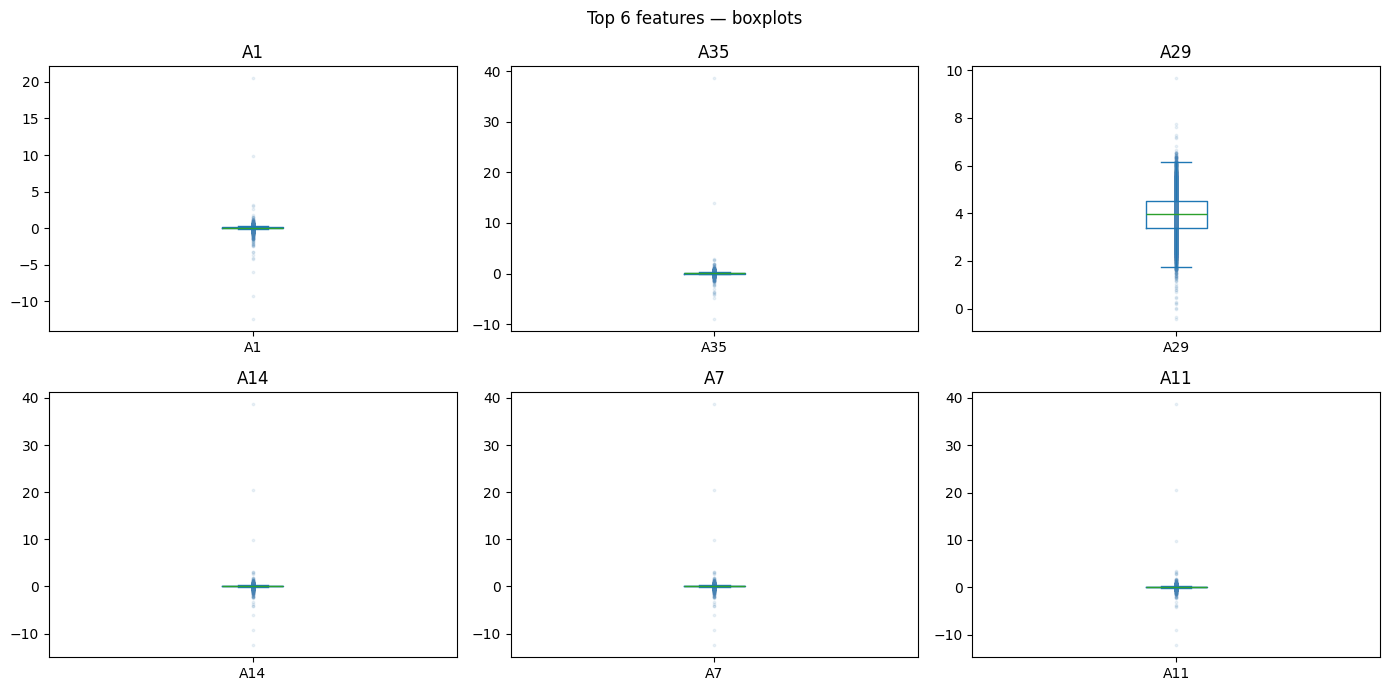

In [116]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), sample_cols):
    X[col].plot.box(ax=ax, showfliers=False)
    ax.scatter([1] * len(X[col]), X[col], alpha=0.1, s=3, color='steelblue')
    ax.set_title(col)

plt.suptitle('Top 6 features — boxplots')
plt.tight_layout()
plt.show()

- TODO chyba usunac moze byc tylko do pokazania ze nic nie widac

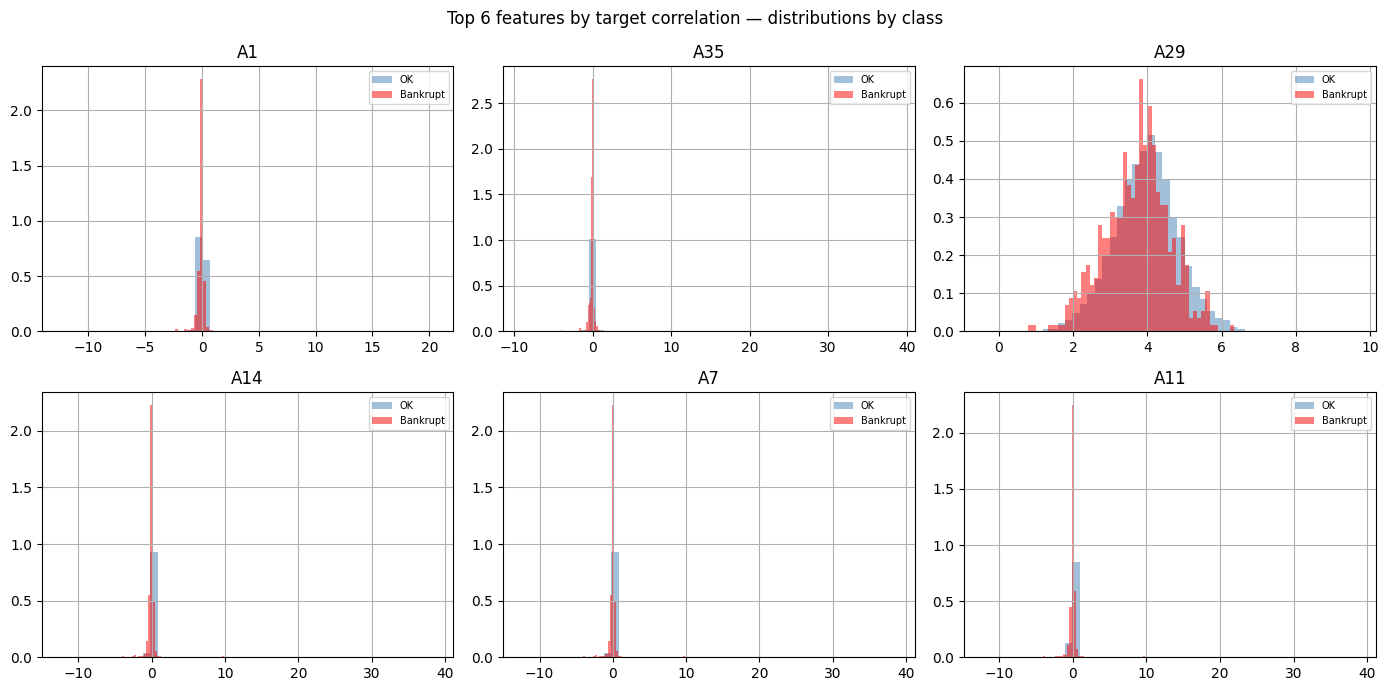

In [117]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), sample_cols):
    X[col][y == 0].hist(ax=ax, bins=50, alpha=0.5, color='steelblue', label='OK', density=True)
    X[col][y == 1].hist(ax=ax, bins=50, alpha=0.5, color='red', label='Bankrupt', density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.suptitle('Top 6 features by target correlation — distributions by class')
plt.tight_layout()
plt.show()

- TODO chyba usunac moze byc tylko do pokazania ze nic nie widac

Usuwamy A37, bo przy 45% braków imputacja medianą stworzyłaby sztuczny rozkład, a informację o płynności pokrywają inne kolumny (A46, A50, A4).

In [118]:
X = X.drop(columns=['A37'])
print("Shape after dropping A37:", X.shape)
print("Remaining missing:", X.isnull().sum().sum())

Shape after dropping A37: (9792, 63)
Remaining missing: 4334


In [119]:
missing_per_row = X.isnull().sum(axis=1)

print("Rows with any missing value:", (missing_per_row > 0).sum(), f"({100*(missing_per_row > 0).mean():.2f}%)")
print()
print("Avg missing features per row:")
print(f"  Class 0 (OK):       {missing_per_row[y==0].mean():.2f}")
print(f"  Class 1 (Bankrupt): {missing_per_row[y==1].mean():.2f}")

Rows with any missing value: 1701 (17.37%)

Avg missing features per row:
  Class 0 (OK):       0.41
  Class 1 (Bankrupt): 1.04


### Uzupełnianie braków

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, bankrupt: {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")
print(f"Test:  {X_test.shape[0]} rows, bankrupt: {(y_test==1).sum()} ({100*(y_test==1).mean():.1f}%)")

Train: 7833 rows, bankrupt: 412 (5.3%)
Test:  1959 rows, bankrupt: 103 (5.3%)


- Zastanowic sie czy napewno tutaj dziele na train i test

In [121]:
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("Missing in train:", X_train.isnull().sum().sum())
print("Missing in test: ", X_test.isnull().sum().sum())

Missing in train: 0
Missing in test:  0


### Analiza i pozbycie się outlierów

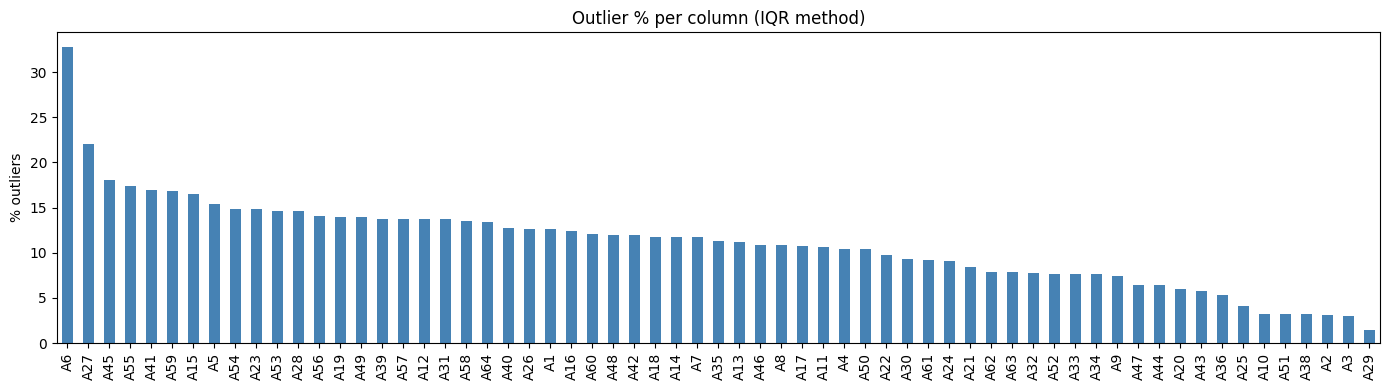

Total outlier cells: 54646 (11.1%)
Rows with at least 1 outlier: 7054 (90%)


In [122]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_train < Q1 - 1.5 * IQR) | (X_train > Q3 + 1.5 * IQR)
outlier_pct = (outlier_mask.sum() / len(X_train) * 100).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
outlier_pct.plot.bar(color='steelblue')
plt.title('Outlier % per column (IQR method)')
plt.ylabel('% outliers')
plt.tight_layout()
plt.show()

print(f"Total outlier cells: {outlier_mask.sum().sum()} ({100 * outlier_mask.sum().sum() / X_train.size:.1f}%)")
print(f"Rows with at least 1 outlier: {outlier_mask.any(axis=1).sum()} ({100 * outlier_mask.any(axis=1).mean():.0f}%)")

In [123]:
print(f"Avg outliers per row — OK:       {outlier_mask[y_train.values == 0].sum(axis=1).mean():.2f}")
print(f"Avg outliers per row — Bankrupt: {outlier_mask[y_train.values == 1].sum(axis=1).mean():.2f}")

Avg outliers per row — OK:       6.80
Avg outliers per row — Bankrupt: 10.07


In [124]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train = X_train.clip(lower=lower, upper=upper, axis=1)
X_test = X_test.clip(lower=lower, upper=upper, axis=1)

print("Outlier cells after clipping:", ((X_train < lower) | (X_train > upper)).sum().sum())

Outlier cells after clipping: 0


### Standaryzacja 

In [125]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### PCA i t-SNE

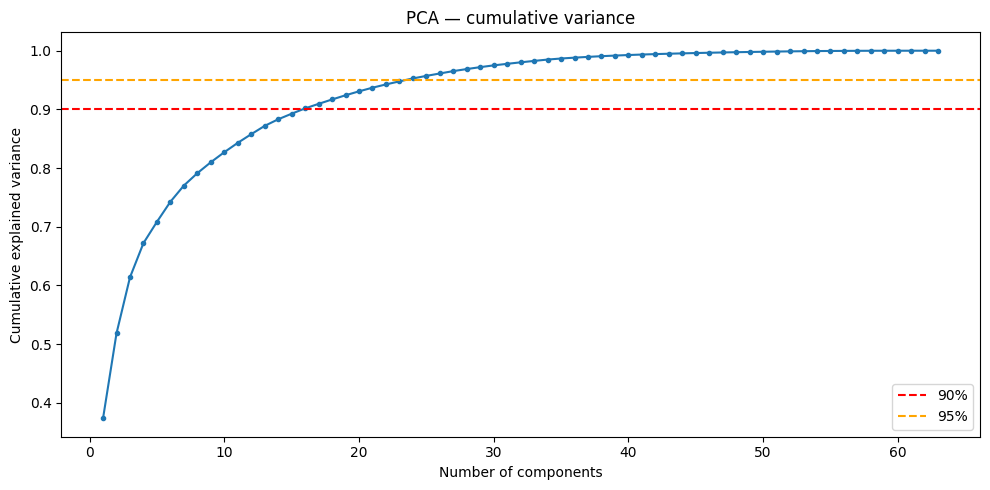

Components for 90%: 16
Components for 95%: 24
First 2 components: 51.8%


In [126]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumvar = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3)
plt.axhline(y=0.90, color='red', linestyle='--', label='90%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — cumulative variance')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Components for 90%: {(cumvar >= 0.90).argmax() + 1}")
print(f"Components for 95%: {(cumvar >= 0.95).argmax() + 1}")
print(f"First 2 components: {cumvar[1]*100:.1f}%")

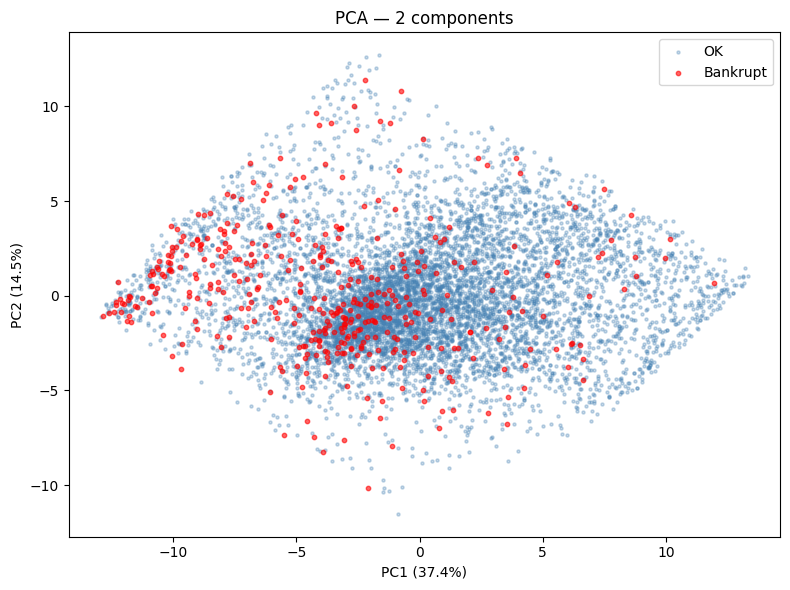

In [127]:
pca2 = PCA(n_components=2)
X_train_pca = pca2.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — 2 components')
plt.legend()
plt.tight_layout()
plt.show()

### t-SNE

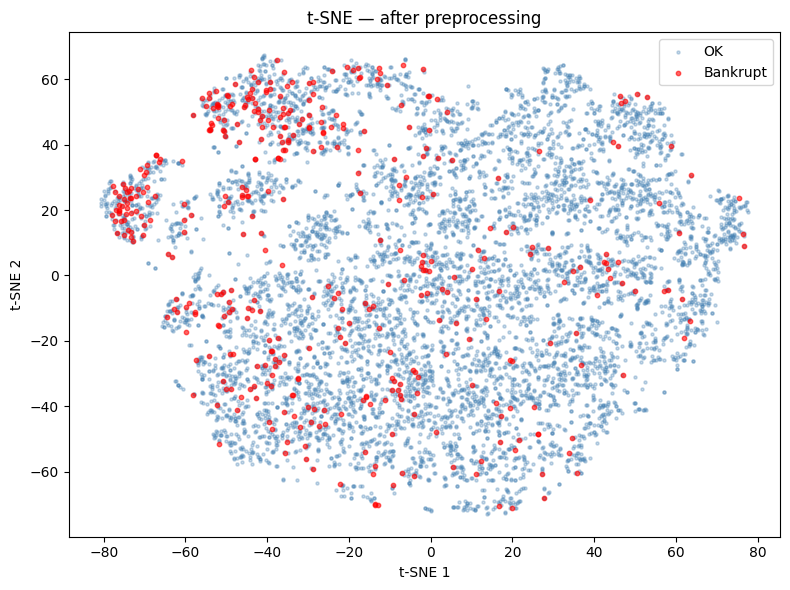

In [128]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], c='red', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE — after preprocessing')
plt.legend()
plt.tight_layout()
plt.show()

### Modelowanie

In [129]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, make_scorer

scoring = {
    'f1': make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'accuracy': make_scorer(accuracy_score),
}

param_grid_gbt = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
}

gbt = GradientBoostingClassifier(random_state=42)
grid_gbt = GridSearchCV(gbt, param_grid_gbt,
                        scoring=scoring,
                        refit='f1', cv=5, n_jobs=-1, verbose=1)
grid_gbt.fit(X_train_scaled, y_train)

cv_gbt = pd.DataFrame(grid_gbt.cv_results_)
cols = ['param_n_estimators', 'param_learning_rate', 'param_max_depth',
        'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall']
print("=== GBT GridSearch results ===")
print(cv_gbt[cols + ['mean_test_f1']].sort_values('mean_test_f1', ascending=False)[cols].to_string(index=False))

y_pred_gbt = grid_gbt.predict(X_test_scaled)
print(f"\nBest params: {grid_gbt.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gbt):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gbt, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_gbt, zero_division=0):.3f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
=== GBT GridSearch results ===
 param_n_estimators  param_learning_rate  param_max_depth  mean_test_accuracy  mean_test_precision  mean_test_recall
                200                 0.20                3                0.96                 0.81              0.42
                200                 0.10                5                0.97                 0.87              0.40
                200                 0.10                3                0.97                 0.89              0.39
                200                 0.20                5                0.96                 0.83              0.40
                100                 0.20                5                0.96                 0.79              0.39
                200                 0.05                5                0.96                 0.89              0.37
                100                 0.20                3                0.96            

In [130]:
from sklearn.metrics import make_scorer

scoring = {
    'f1': make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'accuracy': make_scorer(accuracy_score),
}

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced', None],
}

svm = SVC(random_state=42)
grid_svm = GridSearchCV(svm, param_grid_svm,
                        scoring=scoring,
                        refit='f1', cv=5, n_jobs=-1, verbose=1)
grid_svm.fit(X_train_scaled, y_train)

cv_svm = pd.DataFrame(grid_svm.cv_results_)
cols = ['param_C', 'param_gamma', 'param_class_weight',
        'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall']
print("=== SVM GridSearch results ===")
print(cv_svm[cols + ['mean_test_f1']].sort_values('mean_test_f1', ascending=False)[cols].to_string(index=False))

y_pred_svm = grid_svm.predict(X_test_scaled)
print(f"\nBest params: {grid_svm.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm, zero_division=0):.3f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
=== SVM GridSearch results ===
 param_C param_gamma param_class_weight  mean_test_accuracy  mean_test_precision  mean_test_recall
   10.00       scale           balanced                0.91                 0.24              0.36
   10.00        auto           balanced                0.91                 0.24              0.36
    1.00       scale           balanced                0.82                 0.16              0.56
    1.00        auto           balanced                0.82                 0.16              0.56
   10.00       scale                NaN                0.95                 0.53              0.15
   10.00        auto                NaN                0.95                 0.53              0.15
    0.10       scale           balanced                0.69                 0.12              0.73
    0.10        auto           balanced                0.69                 0.12              0.73
    0.10       sc

In [133]:
from itables import show

def gbt_name(row):
    return f"GBT lr={row['param_learning_rate']} depth={row['param_max_depth']} n={row['param_n_estimators']}"

def svm_name(row):
    return f"SVM C={row['param_C']} {row['param_class_weight']}"

gbt_table = cv_gbt[['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].copy()
gbt_table.insert(0, 'model', cv_gbt.apply(gbt_name, axis=1))

svm_table = cv_svm[['mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].copy()
svm_table.insert(0, 'model', cv_svm.apply(svm_name, axis=1))

combined = pd.concat([gbt_table, svm_table], ignore_index=True)
combined.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
combined = combined.round(3)

show(combined, scrollY="400px")

Loading ITables v2.7.3 from the internet... (need help?)


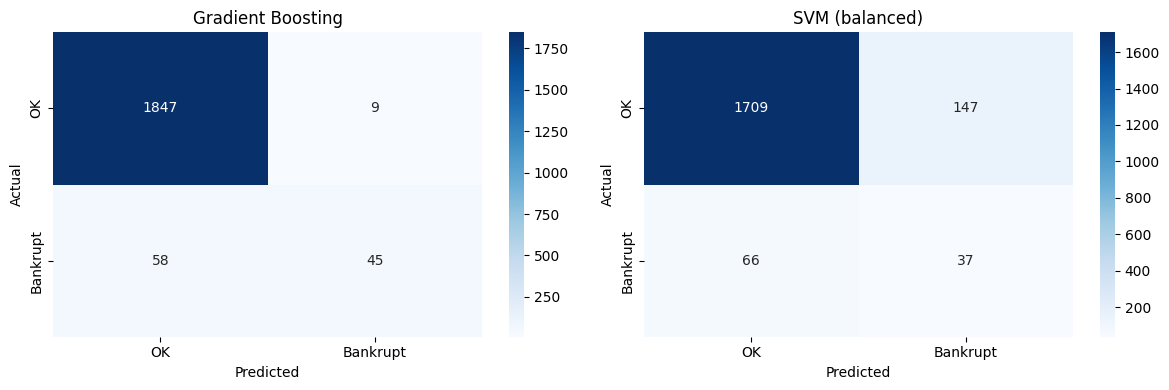

In [131]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, name in zip(axes, [y_pred_gbt, y_pred_svm], ['Gradient Boosting', 'SVM (balanced)']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['OK', 'Bankrupt'],
                yticklabels=['OK', 'Bankrupt'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()

TODO
- porownanie z innymi metodami uzupelnienia brakow
- porownanie z clippingiem outliera i bez clippingu
- porownanie z standaryzacją, normalizacja i bez skalowania
- porownanie z pca i bez pca bez standrayzacji i clippingu